# Model Exp

## setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression


## load data

In [2]:
import sys
from pathlib import Path

# Add repo root to sys.path so `src` is importable from the notebooks/ dir
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data.load_data import load_data
from src.data.clean_data import clean_data
from src.data.preprocess import preprocess
from src.data.data_split import data_split
from src.features.features_engineer import features_engineer
from src.models.models import xgboost
from src.services.metrics import evaluate_model

/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load data
df = load_data()

# clean data
df_clean = clean_data(df)

# preprocess data
df_prep = preprocess(df_clean)

# feature engineering
df_feat = features_engineer(df_prep)

# data split
X_train, X_test, y_train, y_test = data_split(df_feat)

In [4]:
X_train

,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,is_prev_address_months_count_available,is_bank_months_count_available,is_device_distinct_emails_8w_available
0,0.3,0.986506,3.258097,40,0.006713,4.778991,AA,6.966024,13096.035018,7850.955007,...,0,7.313887,0,INTERNET,2.846353,linux,1,0,1,1
1,0.8,0.617426,4.499810,20,0.010044,2.752450,AD,7.413970,9223.283431,5745.251481,...,0,7.313887,0,INTERNET,1.473356,other,1,0,1,1
2,0.8,0.996707,2.708050,40,0.012241,2.710725,AB,6.999422,4471.472149,5471.988958,...,0,5.303305,0,INTERNET,3.166764,windows,0,1,1,1
3,0.6,0.475100,2.708050,30,0.006967,2.685631,AB,8.155936,14431.993621,6755.344479,...,0,5.303305,0,INTERNET,2.785987,linux,1,1,1,1
4,0.9,0.842307,3.401197,40,1.908449,4.153918,AA,7.757906,7601.511579,5124.046930,...,0,5.303305,0,INTERNET,1.556680,other,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794984,0.9,0.670058,4.615121,20,0.030853,2.787762,AB,7.891705,3445.858573,4733.316718,...,0,5.303305,0,INTERNET,0.109091,windows,0,0,1,1
794985,0.6,0.369424,2.772589,30,0.016682,2.798798,AD,6.690842,5361.336674,5022.548146,...,0,6.908755,0,INTERNET,2.245138,windows,1,1,1,1
794986,0.6,0.245233,3.713572,20,0.012243,2.761277,AB,7.061334,7011.340079,3736.164978,...,0,5.303305,0,INTERNET,0.437217,windows,0,0,1,1
794987,0.1,0.653664,2.302585,20,0.008469,2.777847,AC,7.996990,3347.956800,3570.438099,...,0,5.303305,0,INTERNET,1.881776,windows,0,0,0,1


In [5]:
# Identify categorical (string) columns once — used by every model below.
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]
print("categorical:", cat_cols)

# Class imbalance ratio (neg / pos) for scale_pos_weight on the tree models.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"pos={pos}, neg={neg}, scale_pos_weight={scale_pos_weight:.1f}")

results = {}


categorical: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
pos=8151, neg=786838, scale_pos_weight=96.5


/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_10296/582839874.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


## Models 

In [6]:
from sklearn.metrics import f1_score

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

results = {}
fitted_models = {}   # name -> {"model": ..., "X_test": ...}, used for interpretation later

def best_f1_threshold(y_true, y_score):
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in thresholds]
    best = int(np.argmax(f1s))
    return thresholds[best], f1s[best]

def score_model(name, train_score, test_score, model=None, X_test_used=None):
    t, _ = best_f1_threshold(y_train, train_score)
    y_pred = (test_score >= t).astype(int)
    results[name] = {**evaluate_model(y_test, y_pred, test_score), "threshold": t}
    if model is not None:
        fitted_models[name] = {"model": model, "X_test": X_test_used}
    return results[name]

/var/folders/0w/dg96nhvx2qdd7h5pk8ft6mhh0000gn/T/ipykernel_10296/3068568569.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()


In [7]:
def plot_feature_importance(model, feature_names, top_n=20, title=None):
    if hasattr(model, "feature_importances_"):      # LGBM / CatBoost / XGBoost
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):                   # logistic regression
        importances = np.abs(model.coef_).ravel()
    else:
        raise ValueError("model exposes neither feature_importances_ nor coef_")

    order = np.argsort(importances)[::-1][:top_n]
    names = np.array(feature_names)[order]
    vals = importances[order]

    plt.figure(figsize=(8, max(4, 0.35 * len(order))))
    plt.barh(names[::-1], vals[::-1])               # largest at top
    plt.xlabel("importance")
    plt.title(title or type(model).__name__)
    plt.tight_layout()
    plt.show()


### Baseline model(logistic regression)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

logreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1)),
])
logreg.fit(X_train, y_train)

score_model("logistic_regression",
            logreg.predict_proba(X_train)[:, 1],
            logreg.predict_proba(X_test)[:, 1],
            model=logreg, X_test_used=X_test)

/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'precision': 0.23841059602649006,
 'recall': 0.2126476719944406,
 'f1_score': 0.22479338842975208,
 'pr_auc': 0.16003868604391647,
 'threshold': np.float64(0.09999999999999999)}

In [9]:
print("train pr_auc:", average_precision_score(y_train, logreg.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  logreg.predict_proba(X_test)[:, 1]))

train pr_auc: 0.12630698748425173
test  pr_auc: 0.16003868604391647


## lightgbm without tuning

I add early stopping bc first try it's overfitting

In [10]:
X_train_lgb, X_test_lgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],          
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

score_model("lightgbm",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1],
            model=lgbm, X_test_used=X_test_lgb)

[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2921
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's average_precision: 0.186661	valid_0's binary_logloss: 0.0550009


{'precision': 0.23081009296148738,
 'recall': 0.3019457956914524,
 'f1_score': 0.26162878217672736,
 'pr_auc': 0.18666114212301957,
 'threshold': np.float64(0.11)}

In [11]:
print("train pr_auc:", average_precision_score(y_train, lgbm.predict_proba(X_train_lgb)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  lgbm.predict_proba(X_test_lgb)[:, 1]))

train pr_auc: 0.22181747380189404
test  pr_auc: 0.18666114212301957


## Catboost without tuning

In [12]:
catboost = CatBoostClassifier(iterations=500, learning_rate=0.02, depth=8,
                              random_seed=42, verbose=0)
catboost.fit(X_train, y_train, cat_features=cat_cols, early_stopping_rounds=50, eval_set=(X_test, y_test))

score_model("catboost",
            catboost.predict_proba(X_train)[:, 1],
            catboost.predict_proba(X_test)[:, 1],
            model=catboost, X_test_used=X_test)

{'precision': 0.2661570535093815,
 'recall': 0.2661570535093815,
 'f1_score': 0.2661570535093815,
 'pr_auc': 0.1912542078893003,
 'threshold': np.float64(0.12)}

In [13]:
print("train pr_auc:", average_precision_score(y_train, catboost.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  catboost.predict_proba(X_test)[:, 1]))

train pr_auc: 0.22933239951540346
test  pr_auc: 0.1912542078893003


## Xgboost without tuning


In [14]:
from xgboost import XGBClassifier

X_train_xgb, X_test_xgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_xgb[c] = X_train_xgb[c].astype("category")
    X_test_xgb[c] = X_test_xgb[c].astype("category")

xgb_model = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=6,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist", enable_categorical=True,   
    eval_metric="aucpr",                            
    early_stopping_rounds=50,                       
    n_jobs=-1, random_state=42,
)
xgb_model.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=False)

score_model("xgboost",
            xgb_model.predict_proba(X_train_xgb)[:, 1],
            xgb_model.predict_proba(X_test_xgb)[:, 1],
            model=xgb_model, X_test_used=X_test_xgb)

{'precision': 0.2388772767990445,
 'recall': 0.27797081306462823,
 'f1_score': 0.25694555965954713,
 'pr_auc': 0.1873230462628581,
 'threshold': np.float64(0.9)}

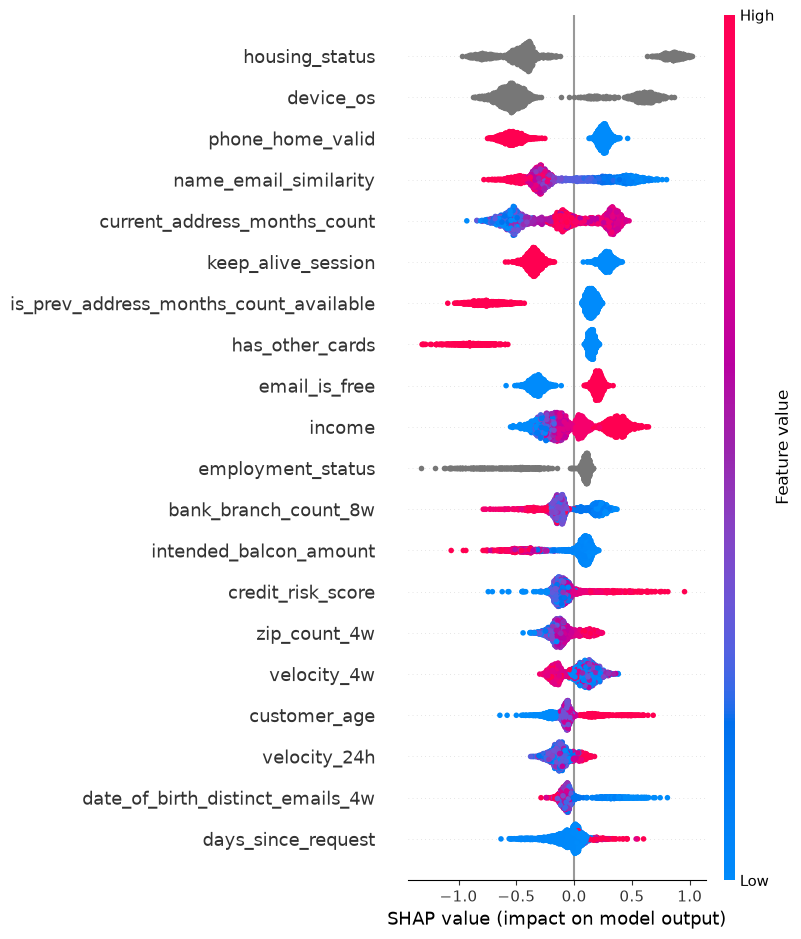

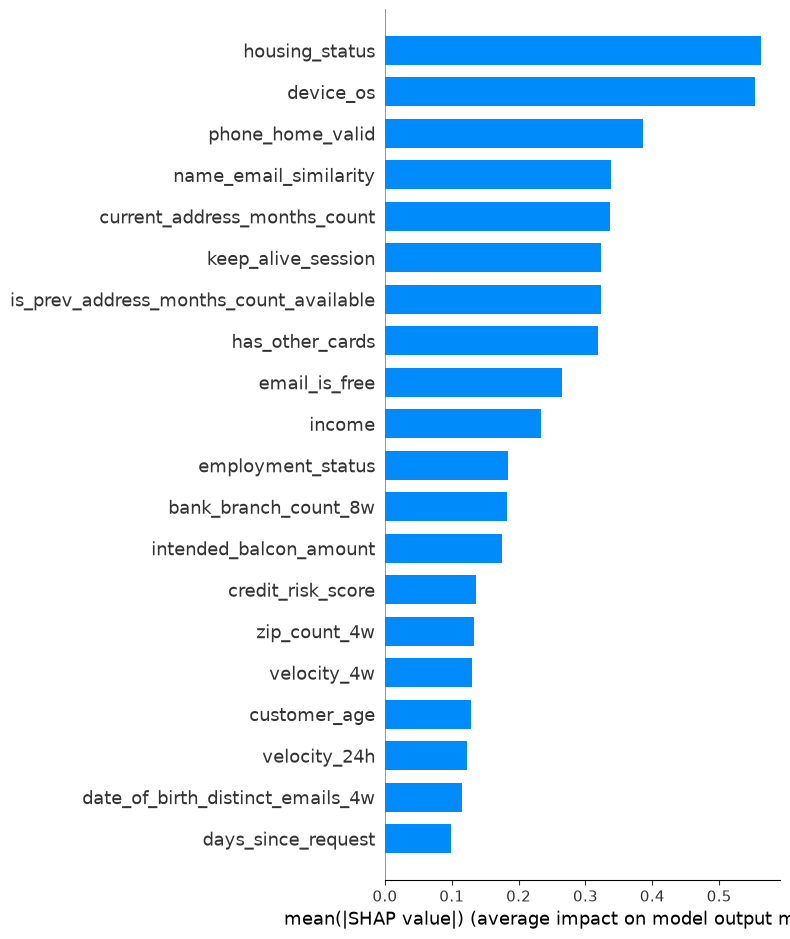

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


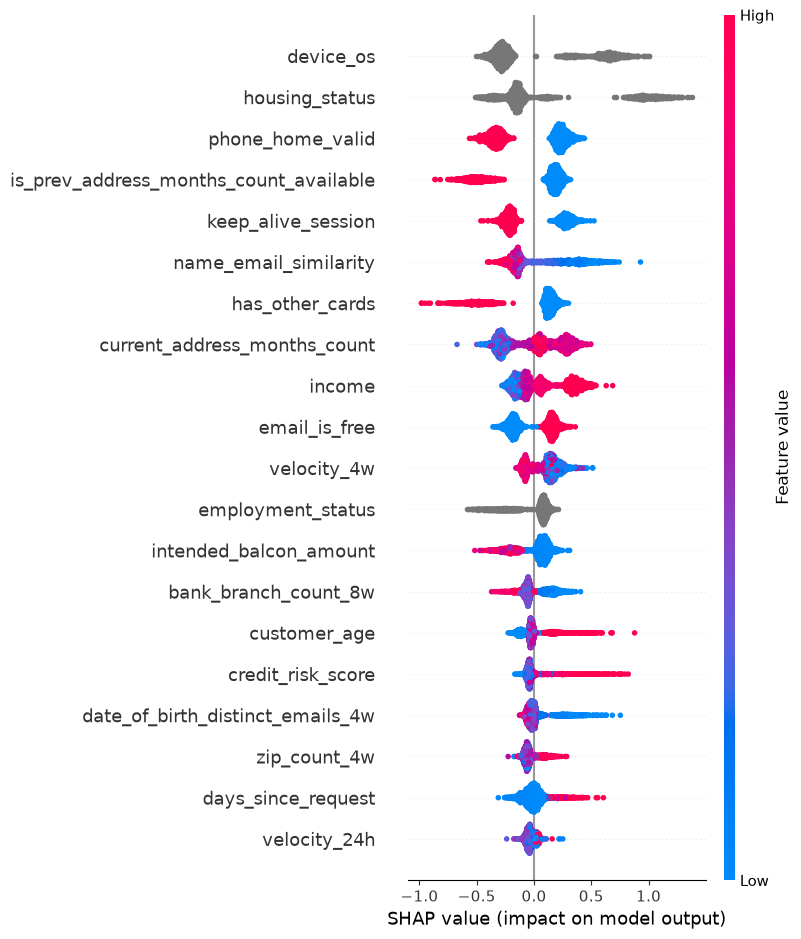

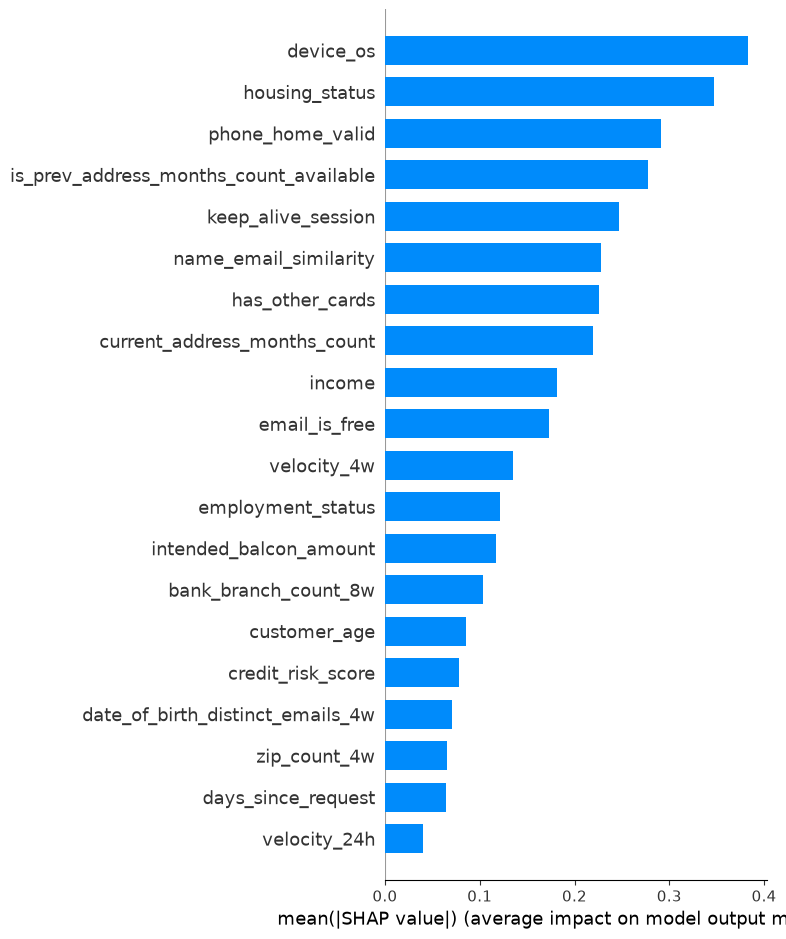

In [16]:
explainer = shap.TreeExplainer(lgbm)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


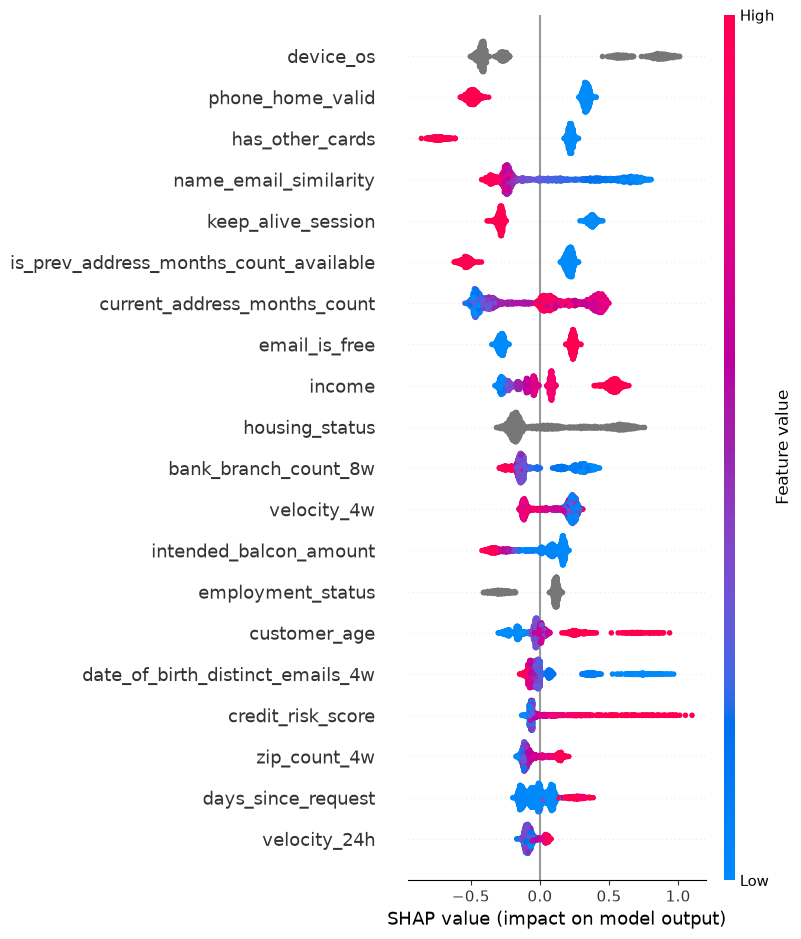

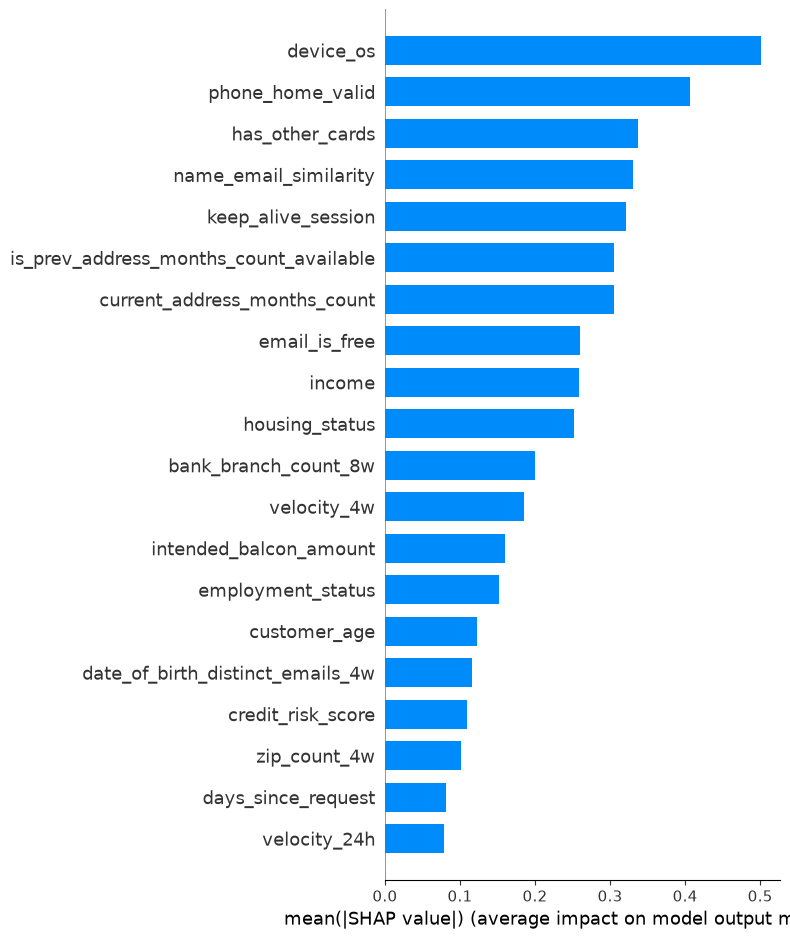

In [ ]:
explainer = shap.TreeExplainer(catboost)          

X_sample = X_test_lgb.sample(2000, random_state=42) 
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)      
shap.summary_plot(shap_values, X_sample, plot_type="bar")   


## SMOTE applied test


In [18]:
from imblearn.over_sampling import SMOTENC

# SMOTENC needs the categorical columns by position.
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("before:", y_train.value_counts().to_dict())
print("after :", y_train_res.value_counts().to_dict())   # now ~50/50


before: {0: 786838, 1: 8151}
after : {0: 786838, 1: 786838}


In [19]:
def to_cat(df):
    df = df.copy()
    for c in cat_cols:
        df[c] = df[c].astype("category")
    return df

In [20]:
logreg = Pipeline(steps=[
    ("prep", ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train_res, y_train_res)

score_model("logistic_regression_smote",
            logreg.predict_proba(X_train)[:, 1],  
            logreg.predict_proba(X_test)[:, 1],
            model=logreg, X_test_used=X_test)

{'precision': 0.20211827007943514,
 'recall': 0.15913829047949965,
 'f1_score': 0.1780715396578538,
 'pr_auc': 0.1130848584844909,
 'threshold': np.float64(0.92)}

In [21]:
X_res_lgb, X_train_lgb, X_test_lgb = to_cat(X_train_res), to_cat(X_train), to_cat(X_test)

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_res_lgb, y_train_res,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

score_model("lightgbm_smote",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1],
            model=lgbm, X_test_used=X_test_lgb)

[LightGBM] [Info] Number of positive: 786838, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3473
[LightGBM] [Info] Number of data points in the train set: 1573676, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's average_precision: 0.141558	valid_0's binary_logloss: 0.0596531


{'precision': 0.1801040312093628,
 'recall': 0.28874218207088254,
 'f1_score': 0.2218366257341164,
 'pr_auc': 0.14155753028301457,
 'threshold': np.float64(0.18000000000000002)}

ummm it's not inc on any baseline model so I decide to not continue :0

## Feature selection + tuning (no SMOTE)

CatBoost-only experiments (best model from above). All fit on months 0–4, early-stop / tune on month 5, evaluate on test:
1. **top-10 features** — top-10 numerical by mutual information + the categoricals, default params
2. **tuning** — Optuna on all features
3. **combine** — top-10 features + Optuna tuning

In [22]:
from sklearn.feature_selection import mutual_info_classif

month_of = df_feat.loc[X_train.index, "month"]
fit_idx = month_of[month_of <= 4].index
val_idx = month_of[month_of == 5].index

X_fit, y_fit = X_train.loc[fit_idx], y_train.loc[fit_idx]
X_val, y_val = X_train.loc[val_idx], y_train.loc[val_idx]
print("fit:", X_fit.shape, "| val:", X_val.shape)

samp = X_train.sample(50_000, random_state=42)
mi = mutual_info_classif(samp[num_cols], y_train.loc[samp.index], random_state=42)
mi_scores = pd.Series(mi, index=num_cols).sort_values(ascending=False)

top10_num = mi_scores.head(15).index.tolist()
selected_features = top10_num + cat_cols          
all_features = num_cols + cat_cols                

print("\ntop-15 numerical:\n", mi_scores.head(15))
print("\nselected_features:", selected_features)

fit: (675666, 29) | val: (119323, 29)

top-15 numerical:
 is_bank_months_count_available            0.010406
keep_alive_session                        0.009996
is_device_distinct_emails_8w_available    0.009494
phone_mobile_valid                        0.009199
email_is_free                             0.009059
proposed_credit_limit                     0.006345
phone_home_valid                          0.005678
is_prev_address_months_count_available    0.004264
customer_age                              0.004207
income                                    0.003422
date_of_birth_distinct_emails_4w          0.002003
credit_risk_score                         0.001935
has_other_cards                           0.001886
current_address_months_count              0.001883
name_email_similarity                     0.001398
dtype: float64

selected_features: ['is_bank_months_count_available', 'keep_alive_session', 'is_device_distinct_emails_8w_available', 'phone_mobile_valid', 'email_is_free', 'pro

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_catboost(name, params, features):
    cats = [c for c in cat_cols if c in features]
    cb = CatBoostClassifier(**params, random_seed=42, verbose=0)
    cb.fit(X_fit[features], y_fit, cat_features=cats,
           eval_set=(X_val[features], y_val), early_stopping_rounds=50)
    score_model(name,
                cb.predict_proba(X_train[features])[:, 1],
                cb.predict_proba(X_test[features])[:, 1],
                model=cb, X_test_used=X_test[features])
    return cb

def make_objective(features):
    cats = [c for c in cat_cols if c in features]
    def objective(trial):
        params = dict(
            iterations=1000,
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            depth=trial.suggest_int("depth", 4, 10),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
        )
        cb = CatBoostClassifier(**params, random_seed=42, verbose=0)
        cb.fit(X_fit[features], y_fit, cat_features=cats,
               eval_set=(X_val[features], y_val), early_stopping_rounds=50)
        # optimize PR-AUC on the held-out validation month (no test leak)
        return average_precision_score(y_val, cb.predict_proba(X_val[features])[:, 1])
    return objective

In [24]:
default_params = dict(iterations=1000, learning_rate=0.02, depth=8)
cb_top10 = run_catboost("catboost_top10", default_params, selected_features)
results["catboost_top10"]

{'precision': 0.25059910989387196,
 'recall': 0.2543432939541348,
 'f1_score': 0.25245732022762546,
 'pr_auc': 0.17813051808675245,
 'threshold': np.float64(0.11)}

## Undersampling (RandomUnderSampler)

Balance the classes by dropping majority rows instead of synthesizing minority ones (SMOTE's counterpart). Applied to **train only**; test is untouched. Threshold is still swept on the real (imbalanced) train distribution.

In [25]:
from imblearn.under_sampling import RandomUnderSampler

# Balance to 1:1 by randomly dropping majority (non-fraud) rows — train only.
rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print("before:", y_train.value_counts().to_dict())
print("after :", y_train_us.value_counts().to_dict())

before: {0: 786838, 1: 8151}
after : {0: 8151, 1: 8151}


In [26]:
logreg = Pipeline(steps=[
    ("prep", ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train_us, y_train_us)

score_model("logistic_regression_under",
            logreg.predict_proba(X_train)[:, 1],
            logreg.predict_proba(X_test)[:, 1],
            model=logreg, X_test_used=X_test)

{'precision': 0.23094425483503983,
 'recall': 0.21160528144544824,
 'f1_score': 0.22085222121486853,
 'pr_auc': 0.15518879007154493,
 'threshold': np.float64(0.91)}

In [27]:
X_us_lgb = to_cat(X_train_us)
X_train_lgb, X_test_lgb = to_cat(X_train), to_cat(X_test)

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_us_lgb, y_train_us,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)],
)

score_model("lightgbm_under",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1],
            model=lgbm, X_test_used=X_test_lgb)

[LightGBM] [Info] Number of positive: 8151, number of negative: 8151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2911
[LightGBM] [Info] Number of data points in the train set: 16302, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[82]	valid_0's average_precision: 0.175274	valid_0's binary_logloss: 0.428468


{'precision': 0.23187537447573398,
 'recall': 0.2689367616400278,
 'f1_score': 0.24903474903474904,
 'pr_auc': 0.17527387273419398,
 'threshold': np.float64(0.88)}

In [28]:
catboost = CatBoostClassifier(iterations=500, learning_rate=0.02, depth=8,
                              random_seed=42, verbose=0)
catboost.fit(X_train_us, y_train_us, cat_features=cat_cols,
             early_stopping_rounds=50, eval_set=(X_test, y_test))

score_model("catboost_under",
            catboost.predict_proba(X_train)[:, 1],
            catboost.predict_proba(X_test)[:, 1],
            model=catboost, X_test_used=X_test)

{'precision': 0.24469067405355494,
 'recall': 0.27623349548297427,
 'f1_score': 0.2595070997225396,
 'pr_auc': 0.1891782692877535,
 'threshold': np.float64(0.9)}

In [29]:
X_us_xgb = to_cat(X_train_us)
X_train_xgb, X_test_xgb = to_cat(X_train), to_cat(X_test)

xgb_model = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    tree_method="hist", enable_categorical=True,
    eval_metric="aucpr", early_stopping_rounds=50,
    n_jobs=-1, random_state=42,
)
xgb_model.fit(X_us_xgb, y_train_us, eval_set=[(X_test_xgb, y_test)], verbose=False)

score_model("xgboost_under",
            xgb_model.predict_proba(X_train_xgb)[:, 1],
            xgb_model.predict_proba(X_test_xgb)[:, 1],
            model=xgb_model, X_test_used=X_test_xgb)

{'precision': 0.208838043965904,
 'recall': 0.3234885337039611,
 'f1_score': 0.2538167938931298,
 'pr_auc': 0.17970575500445568,
 'threshold': np.float64(0.91)}

In [30]:
results_df = pd.DataFrame(results).T.sort_values("f1_score", ascending=False)
results_df

,precision,recall,f1_score,pr_auc,threshold
catboost,0.266157,0.266157,0.266157,0.191254,0.12
lightgbm,0.230810,0.301946,0.261629,0.186661,0.11
catboost_under,0.244691,0.276233,0.259507,0.189178,0.90
xgboost,0.238877,0.277971,0.256946,0.187323,0.90
xgboost_under,0.208838,0.323489,0.253817,0.179706,0.91
catboost_top10,0.250599,0.254343,0.252457,0.178131,0.11
lightgbm_under,0.231875,0.268937,0.249035,0.175274,0.88
logistic_regression,0.238411,0.212648,0.224793,0.160039,0.10
lightgbm_smote,0.180104,0.288742,0.221837,0.141558,0.18
logistic_regression_under,0.230944,0.211605,0.220852,0.155189,0.91


## Model Interpretation

Pick the best model from `results` (by PR-AUC) and explain it: built-in feature importance +
SHAP (beeswarm shows importance *and* direction; bar shows the global ranking).

best model by pr_auc: catboost
{'precision': 0.2661570535093815, 'recall': 0.2661570535093815, 'f1_score': 0.2661570535093815, 'pr_auc': 0.1912542078893003, 'threshold': np.float64(0.12)}


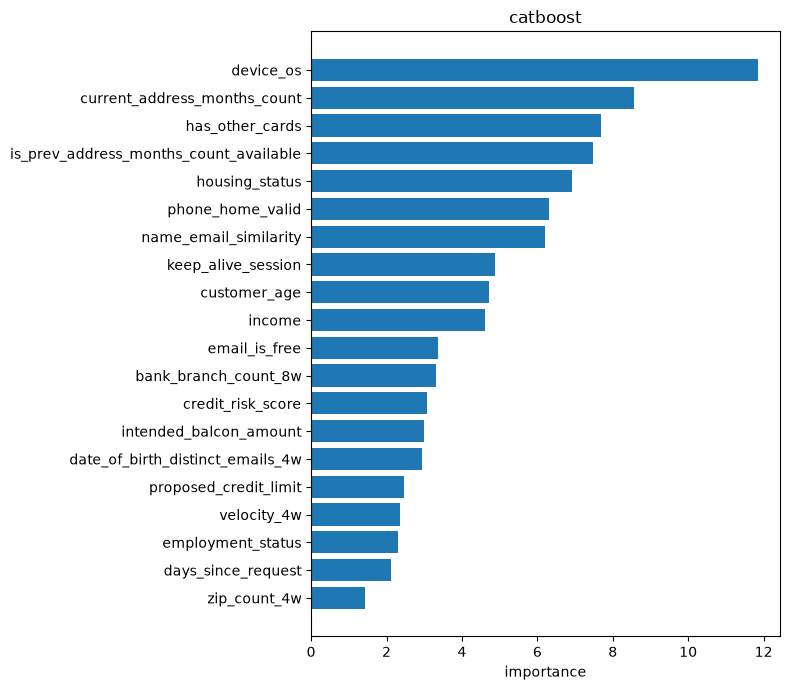

In [31]:
from sklearn.pipeline import Pipeline

METRIC = "pr_auc"  
best_name = max(results, key=lambda k: results[k][METRIC])
model = fitted_models[best_name]["model"]
X_te = fitted_models[best_name]["X_test"]
print(f"best model by {METRIC}: {best_name}")
print(results[best_name])

if isinstance(model, Pipeline):
    clf = model.named_steps["clf"]
    names = model.named_steps["prep"].get_feature_names_out()
    plot_feature_importance(clf, names, title=best_name)
else:
    plot_feature_importance(model, X_te.columns, title=best_name)

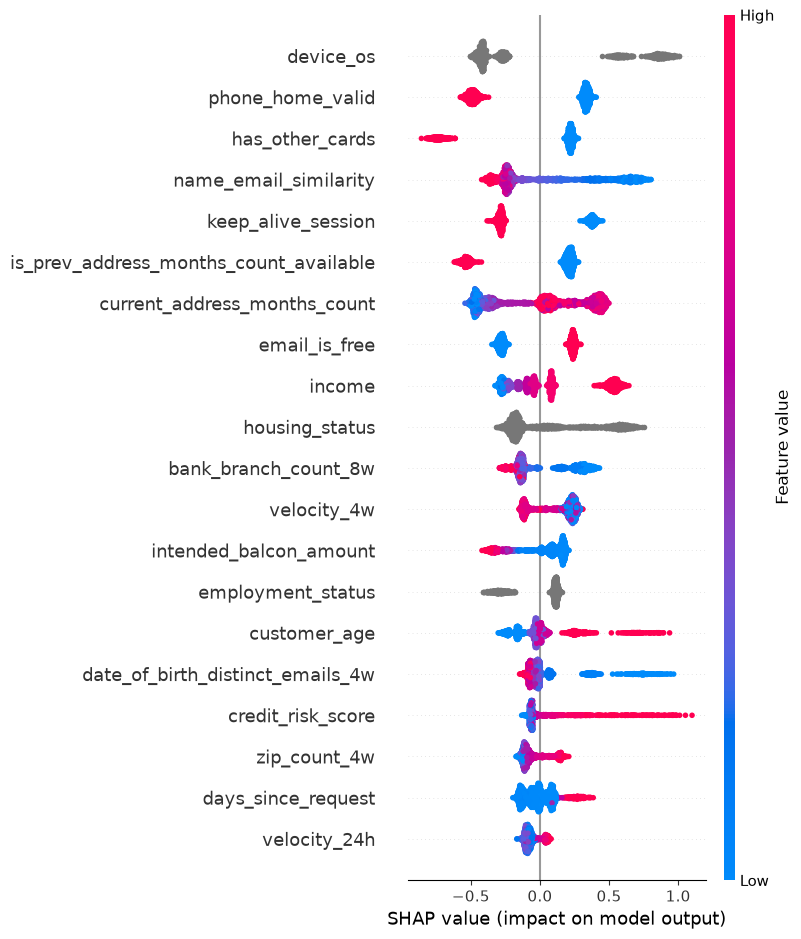

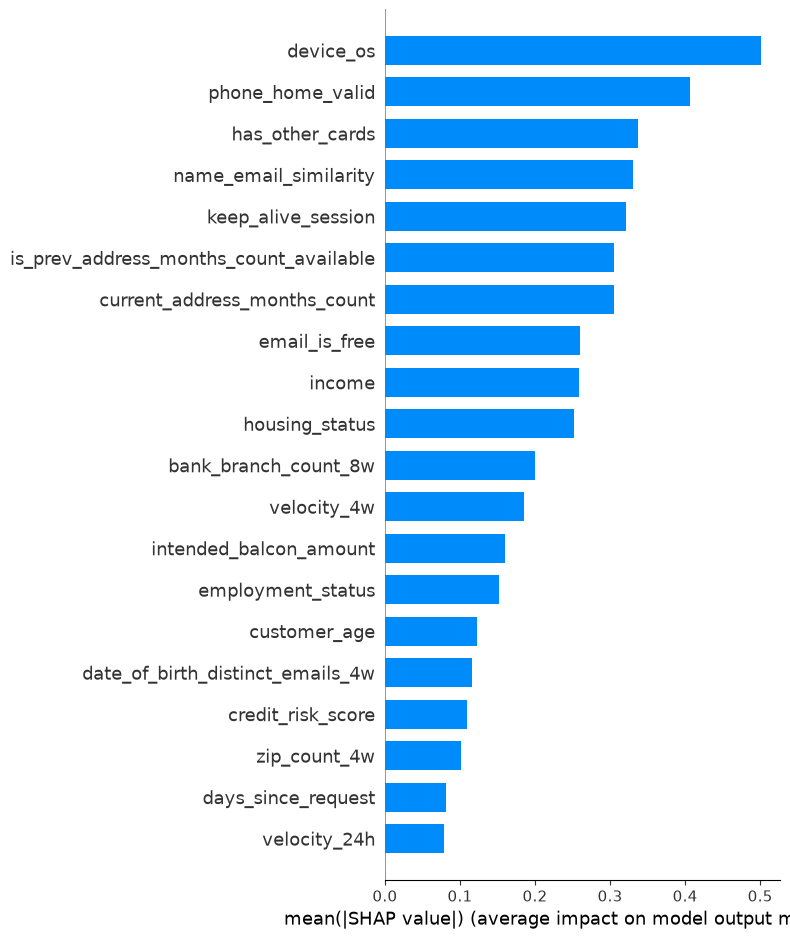

In [32]:
import shap
from catboost import CatBoostClassifier, Pool

X_samp = X_te.sample(min(2000, len(X_te)), random_state=42)

if isinstance(model, Pipeline):
    print("Best model is logistic regression — see coefficient importance above (SHAP skipped).")
elif isinstance(model, CatBoostClassifier):
    cats = [c for c in cat_cols if c in X_samp.columns]
    sv = model.get_feature_importance(Pool(X_samp, cat_features=cats), type="ShapValues")
    shap_values = sv[:, :-1]                      
    shap.summary_plot(shap_values, X_samp)
    shap.summary_plot(shap_values, X_samp, plot_type="bar")
else:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_samp)
    if isinstance(shap_values, list):            # some versions return [class0, class1]
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_samp)
    shap.summary_plot(shap_values, X_samp, plot_type="bar")

## Error Analysis

Where does the winning model make mistakes, on the honest ~1.1%-prevalence test set? Confusion
matrix + score distribution, then errors broken down by `customer_age` group (fairness), by
`device_os`, and the worst false negatives / false positives for manual inspection.

model: catboost | threshold: 0.120

confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[200021   2112]
 [  2112    766]]

               precision    recall  f1-score   support

           0      0.990     0.990     0.990    202133
           1      0.266     0.266     0.266      2878

    accuracy                          0.979    205011
   macro avg      0.628     0.628     0.628    205011
weighted avg      0.979     0.979     0.979    205011



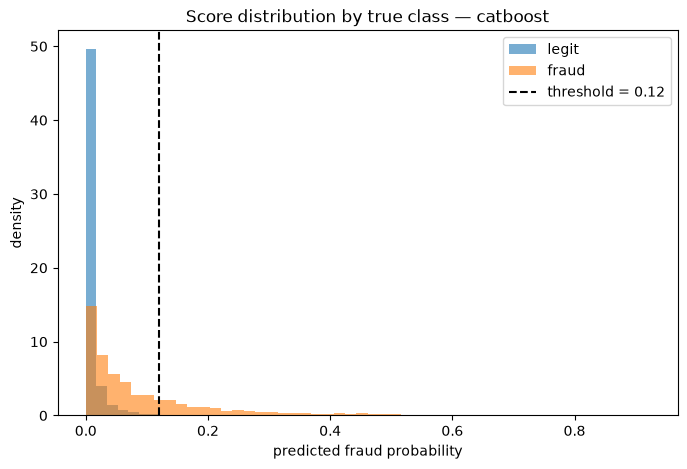

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

thr = results[best_name]["threshold"]
score = model.predict_proba(X_te)[:, 1]

err = X_test.copy()                
err["y_true"] = y_test.values
err["score"] = score
err["y_pred"] = (err["score"] >= thr).astype(int)
err["error_type"] = np.select(
    [(err.y_true == 1) & (err.y_pred == 1),
     (err.y_true == 0) & (err.y_pred == 0),
     (err.y_true == 0) & (err.y_pred == 1)],
    ["TP", "TN", "FP"], default="FN")

print(f"model: {best_name} | threshold: {thr:.3f}\n")
print("confusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(confusion_matrix(err.y_true, err.y_pred))
print("\n", classification_report(err.y_true, err.y_pred, digits=3))

plt.figure(figsize=(8, 5))
plt.hist(err.loc[err.y_true == 0, "score"], bins=50, density=True, alpha=.6, label="legit")
plt.hist(err.loc[err.y_true == 1, "score"], bins=50, density=True, alpha=.6, label="fraud")
plt.axvline(thr, color="k", ls="--", label=f"threshold = {thr:.2f}")
plt.xlabel("predicted fraud probability"); plt.ylabel("density")
plt.title(f"Score distribution by true class — {best_name}"); plt.legend(); plt.show()

In [ ]:
err["age_group"] = np.where(err["customer_age"] >= 50, ">=50", "<50")

def rates(sub):
    tp = ((sub.y_true == 1) & (sub.y_pred == 1)).sum()
    fn = ((sub.y_true == 1) & (sub.y_pred == 0)).sum()
    fp = ((sub.y_true == 0) & (sub.y_pred == 1)).sum()
    tn = ((sub.y_true == 0) & (sub.y_pred == 0)).sum()
    return pd.Series({"n": len(sub), "frauds": int(tp + fn),
                      "recall_TPR": tp / (tp + fn) if (tp + fn) else np.nan,
                      "FPR": fp / (fp + tn) if (fp + tn) else np.nan})

age_tbl = err.groupby("age_group").apply(rates)
print("Errors by customer_age group:\n", age_tbl, "\n")
print(f"equal-opportunity  (TPR ratio): {age_tbl.recall_TPR.min() / age_tbl.recall_TPR.max():.3f}")
print(f"predictive-equality (FPR ratio): {age_tbl.FPR.min() / age_tbl.FPR.max():.3f}")

dev = (err[err.y_true == 1].groupby("device_os")
       .agg(frauds=("y_true", "size"), caught=("y_pred", "sum")))
dev["recall"] = dev["caught"] / dev["frauds"]
print("\nFraud recall by device_os:\n", dev)

Errors by customer_age group:
                   n  frauds  recall_TPR       FPR
age_group                                        
<50        171232.0  1889.0    0.191106  0.006584
>=50        33779.0   989.0    0.409505  0.030406 

equal-opportunity  (TPR ratio): 0.467
predictive-equality (FPR ratio): 0.217

Fraud recall by device_os:
            frauds  caught    recall
device_os                          
linux         481      55  0.114345
macintosh     208      54  0.259615
other         568      48  0.084507
windows      1602     603  0.376404
x11            19       6  0.315789


In [35]:
cols = ["customer_age", "income", "credit_risk_score", "name_email_similarity",
        "proposed_credit_limit", "device_os", "score"]

print("Top 10 FALSE NEGATIVES (actual fraud, lowest fraud score — most confident misses):")
display(err[err.error_type == "FN"].nsmallest(10, "score")[cols])

print("\nTop 10 FALSE POSITIVES (legit, highest fraud score):")
display(err[err.error_type == "FP"].nlargest(10, "score")[cols])

Top 10 FALSE NEGATIVES (actual fraud, lowest fraud score — most confident misses):


,customer_age,income,credit_risk_score,name_email_similarity,proposed_credit_limit,device_os,score
890596,30,0.7,103,0.878457,5.303305,linux,0.000256
890236,40,0.6,72,0.386186,5.303305,other,0.000266
904308,40,0.9,132,0.516058,5.303305,linux,0.000301
852416,30,0.3,70,0.626779,5.303305,linux,0.000357
843793,30,0.4,166,0.396141,5.303305,other,0.000367
907111,30,0.8,135,0.724995,5.303305,linux,0.000483
981016,30,0.9,126,0.231963,5.303305,other,0.000556
943791,20,0.2,90,0.629028,5.303305,linux,0.000566
925877,30,0.2,107,0.466246,5.303305,other,0.000624
961145,30,0.6,71,0.394438,5.303305,linux,0.000632



Top 10 FALSE POSITIVES (legit, highest fraud score):


,customer_age,income,credit_risk_score,name_email_similarity,proposed_credit_limit,device_os,score
876591,50,0.9,299,0.033706,7.601402,windows,0.872201
851342,60,0.9,286,0.340408,7.601402,windows,0.804076
940079,40,0.9,295,0.082349,7.601402,windows,0.759269
867254,50,0.9,257,0.152786,7.601402,windows,0.738238
977593,30,0.9,354,0.148323,7.313887,windows,0.680818
863397,40,0.9,273,0.092390,7.601402,other,0.667929
795223,40,0.9,294,0.128731,5.303305,windows,0.666762
907882,60,0.9,240,0.109090,7.550135,windows,0.665760
848958,60,0.9,227,0.065250,7.601402,windows,0.653284
908649,40,0.9,246,0.111564,7.601402,windows,0.645037
